# Example 16: LEO PNT &mdash; a low-Earth-orbit navigation constellation

This is the Earth companion to the Mars tutorial (Example&nbsp;15). Here we build a **low-Earth-orbit
(LEO) Position, Navigation and Timing constellation** &mdash; the kind of dense small-satellite fleet
proposed to *augment* GPS with strong, close-range signals &mdash; and evaluate the positioning service
it delivers to a user in **San Francisco**.

LEO adds a force that higher orbits can ignore: **atmospheric drag**. LuPNT models it with a
Harris-Priester density model, alongside the Earth gravity field, so the whole study runs on the
native `NBodyDynamics` propagator and Earth reference frames.

We will

1. build an Earth force model with **$J_2$ (and higher harmonics) plus atmospheric drag**,
2. show that **neglecting drag** throws a LEO satellite's predicted position off by kilometres within
   days &mdash; why a LEO PNT provider must model it,
3. lay out a **110-satellite Walker constellation** at 600&nbsp;km and propagate it,
4. visualize the **orbits** and **ground tracks**,
5. map **coverage and PDOP** over the surface, and
6. run a **pseudorange least-squares positioning** simulation at San Francisco.

Only the central body and its forces change from the lunar and Mars examples; the workflow is the same.


## 0. Imports and Earth data

Earth is a first-class body in LuPNT: `Body.Earth` gives its gravity model, `GCRF` / `ITRF` are the
inertial and Earth-fixed frames, and `plot_body` already knows Earth's texture.


In [1]:
import os, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from PIL import Image

for _b in [Path.cwd(), *Path.cwd().parents]:
    if (_b / "python/pylupnt/__init__.py").exists():
        sys.path.insert(0, str((_b / "python").resolve()))
        if (_b / "data/LuPNT_data/ephemeris").is_dir():
            os.environ["LUPNT_DATA_PATH"] = str((_b / "data/LuPNT_data").resolve())
        break
import pylupnt as pnt

np.set_printoptions(precision=4, suppress=True)
RAD, DEG = pnt.RAD, pnt.DEG
LUPNT_DATA = os.environ["LUPNT_DATA_PATH"]

earth_pm = pnt.Body.Earth()
GM_EARTH = float(earth_pm.GM)  # [m^3/s^2]
R_EARTH = float(earth_pm.R)  # [m]
EARTH_MAP = np.asarray(
    Image.open(os.path.join(LUPNT_DATA, "topo", "earth_surface.jpg"))
)
EARTH_MAP = np.fliplr(
    np.flipud(EARTH_MAP)
)  # flip to match the coordinate system of the Earth-fixed frame

print(f"GM_EARTH = {GM_EARTH:.6e} m^3/s^2")
print(f"R_EARTH  = {R_EARTH/1e3:.1f} km")
print(
    f"frames   : {earth_pm.inertial_frame} (inertial) / {earth_pm.fixed_frame} (Earth-fixed)"
)

# Host heavy interactive figures on lupnt-doc-assets instead of embedding them.
import sys as _sys
from pathlib import Path as _Path

for _p in [_Path.cwd(), *_Path.cwd().parents]:
    if (_p / "python" / "examples" / "_doc_assets.py").exists():
        _sys.path.insert(0, str(_p / "python" / "examples"))
        break
from _doc_assets import embed_plotly, embed_cesium_scene

[00.00][PyLuPNT] Initializing


GM_EARTH = 3.986004e+14 m^3/s^2
R_EARTH  = 6378.1 km
frames   : Frame.GCRF (inertial) / Frame.ITRF (Earth-fixed)


## 1. Force model: $J_2$ gravity **and** atmospheric drag

`Body.Earth(n, m, gravity_file)` loads the EGM96 field (we keep degree/order $4\times4$ &mdash; $J_2$
dominates the low-orbit dynamics). We then switch on **atmospheric drag** with
`set_drag_coeff`, which sets the ballistic coefficient $B = C_D A/m$; LuPNT evaluates the drag with a
Harris-Priester density model (valid 100&ndash;1000&nbsp;km) that needs no extra data.

`compute_accelerations(..., decompose_gravity=True)` shows the resulting budget: $J_2$ is four orders
of magnitude below the central term, and drag is another few orders below that &mdash; but drag is the
one force here that *removes energy*, so its effect accumulates secularly.


In [2]:
N_GRAV = 4  # EGM96 degree/order (J2-dominated for LEO)
CD, AREA, MASS = 2.2, 1.0, 100.0  # drag coefficient, area [m^2], mass [kg]
BSTAR = CD * AREA / MASS  # ballistic coefficient B = CD*A/m [m^2/kg]

earth = pnt.Body.Earth(N_GRAV, N_GRAV, gravity_file="EGM96.cof")
GCRF, ITRF = earth.inertial_frame, earth.fixed_frame


def make_dynamics(drag=True, integrator=pnt.IntegratorType.RK4, step=30.0):
    dyn = pnt.NBodyDynamics()
    dyn.set_frame(GCRF)
    dyn.set_units(pnt.SI_UNITS)
    dyn.add_body(earth)  # Earth gravity field (incl. J2)
    dyn.set_integrator(integrator)
    dyn.set_time_step(step)
    if drag:
        dyn.set_drag_coeff(BSTAR)  # Harris-Priester atmospheric drag
    return dyn


dyn = make_dynamics(drag=True)
EPOCH = pnt.gregorian_to_time(2035, 1, 1, 0, 0, 0)

# acceleration budget at three LEO altitudes (circular, 55 deg)
print(f"Ballistic coefficient B = CD*A/m = {BSTAR:.3f} m^2/kg\n")
print(f"{'altitude':>10} {'|a_grav|':>12} {'|a_J2|':>12} {'|a_drag|':>12}")
for alt in (400e3, 600e3, 800e3):
    rv = pnt.classical_to_cart(
        np.array([R_EARTH + alt, 0.001, 55 * RAD, 0, 0, 0]), GM_EARTH
    )
    acc = dyn.compute_accelerations(EPOCH, rv, decompose_gravity=True)
    m = {k: float(np.linalg.norm(v)) for k, v in acc.items()}
    print(
        f"{alt/1e3:>7.0f} km {m['EARTH_gravity']:>12.4e} {m.get('EARTH_J2',0):>12.3e} "
        f"{m.get('drag',0):>12.3e}"
    )

Ballistic coefficient B = CD*A/m = 0.022 m^2/kg

  altitude     |a_grav|       |a_J2|     |a_drag|
    400 km   8.6933e+00    1.253e-02    3.277e-06
    600 km   8.2022e+00    1.115e-02    2.299e-07
    800 km   7.7515e+00    9.958e-03    2.683e-08


## 2. Why drag matters for a LEO PNT provider

A navigation satellite broadcasts its own predicted position; any error there flows straight into the
user's fix. To show what drag does, we propagate one satellite at the constellation altitude twice
&mdash; **with** and **without** drag &mdash; from the same initial state, and track how far apart the two
predictions drift. Because both runs use the same accurate integrator (RK8), numerical error cancels
in the difference, isolating the drag effect: an unmodeled satellite falls behind along-track and its
position error grows to **hundreds of metres to kilometres within days** &mdash; unacceptable for PNT.


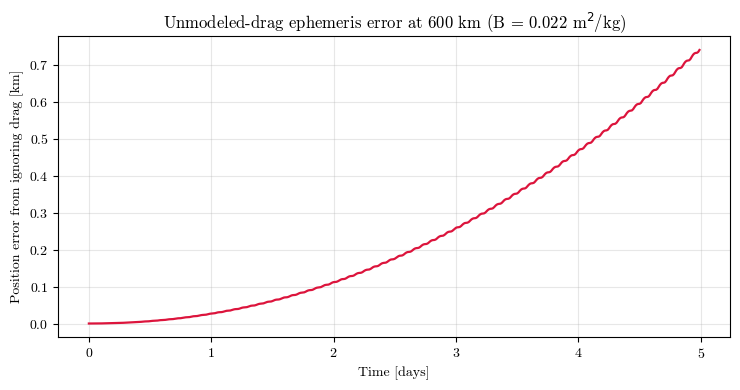

Neglecting drag mispredicts the satellite by 0.74 km after 5 days.


In [3]:
ALT_DEMO = 600e3
rv_demo = pnt.classical_to_cart(
    np.array([R_EARTH + ALT_DEMO, 0.0005, 55 * RAD, 0, 0, 0]), GM_EARTH
)
t_demo = EPOCH + np.arange(0.0, 5 * 86400.0, 900.0)  # 5 days, 15-min samples

dyn_drag = make_dynamics(drag=True, integrator=pnt.IntegratorType.RK8, step=60.0)
dyn_nodrag = make_dynamics(drag=False, integrator=pnt.IntegratorType.RK8, step=60.0)
xd = np.asarray(dyn_drag.propagate(rv_demo, t_demo))
xn = np.asarray(dyn_nodrag.propagate(rv_demo, t_demo))
sep = np.linalg.norm(xd[:, :3] - xn[:, :3], axis=1)  # drag-induced position error [m]
days = (t_demo - EPOCH) / 86400.0

fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(days, sep / 1e3, color="crimson", lw=1.6)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Position error from ignoring drag [km]")
ax.set_title(
    f"Unmodeled-drag ephemeris error at {ALT_DEMO/1e3:.0f} km (B = {BSTAR:.3f} m$^2$/kg)"
)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print(
    f"Neglecting drag mispredicts the satellite by {sep[-1]/1e3:.2f} km after {days[-1]:.0f} days."
)

## 3. A 110-satellite Walker constellation

We use a **Walker&nbsp;$\delta$** pattern $110/10/1$: 110 satellites in 10 planes, circular orbits at
**600&nbsp;km** and **$55^\circ$** inclination &mdash; enough to give a mid-latitude user like San
Francisco continuous multi-satellite visibility.

Unlike Mars (Example&nbsp;15), Earth needs no special design frame: `GCRF`'s pole sits within a
fraction of a degree of Earth's spin axis, so an inclination specified in `GCRF` *is* the geographic
inclination to well within our purposes. We build each satellite's state with `classical_to_cart`
directly in `GCRF`.


In [4]:
N_SAT, N_PLANES, F_WALKER = 110, 10, 1
SATS_PER_PLANE = N_SAT // N_PLANES
ALT = 600e3
A_SMA = R_EARTH + ALT
INC = 55.0 * RAD
PERIOD = 2 * np.pi * np.sqrt(A_SMA**3 / GM_EARTH)


def walker_elements(T, P, Fp, a, e, inc):
    spp = T // P
    coes = []
    for p in range(P):
        raan = p * 2 * np.pi / P
        for s in range(spp):
            M = (s * 2 * np.pi / spp + p * 2 * np.pi * Fp / T) % (2 * np.pi)
            coes.append([a, e, inc, raan, 0.0, M])
    return np.array(coes)


COES = walker_elements(N_SAT, N_PLANES, F_WALKER, A_SMA, 0.001, INC)
RV0 = np.array([pnt.classical_to_cart(coe, GM_EARTH) for coe in COES])  # GCRF states

print(
    f"Walker {N_SAT}/{N_PLANES}/{F_WALKER}: {N_PLANES} planes x {SATS_PER_PLANE} sats"
)
print(
    f"  altitude {ALT/1e3:.0f} km  (a = {A_SMA/1e3:.0f} km),  inclination {INC*DEG:.0f} deg"
)
print(f"  orbital period {PERIOD/60:.1f} min  ({86400/PERIOD:.1f} revs/day)")

Walker 110/10/1: 10 planes x 11 sats
  altitude 600 km  (a = 6978 km),  inclination 55 deg
  orbital period 96.7 min  (14.9 revs/day)


### Propagate the fleet with $J_2$ + drag

We propagate all 110 satellites for **two orbital periods** at 1-minute sampling with `NBodyDynamics`
(fixed-step RK4 &mdash; more than accurate enough for coverage geometry), then rotate the inertial `GCRF`
states into the Earth-fixed `ITRF` frame with `convert_frame` for ground tracks and user geometry.


In [5]:
T_SIM = 2 * PERIOD
DT = 60.0
TS = EPOCH + np.arange(0.0, T_SIM, DT)
N_T = len(TS)

POS_GCRF = np.zeros((N_SAT, N_T, 3))
for k in range(N_SAT):
    POS_GCRF[k] = np.asarray(dyn.propagate(RV0[k], TS))[:, :3]

POS_ITRF = np.zeros((N_SAT, N_T, 3))
for k in range(N_SAT):
    POS_ITRF[k] = np.asarray(pnt.convert_frame(TS, POS_GCRF[k], GCRF, ITRF))[:, :3]

print(
    f"Propagated {N_SAT} satellites over {T_SIM/60:.0f} min ({N_T} epochs) with J2 + drag"
)

Propagated 110 satellites over 193 min (194 epochs) with J2 + drag


## 4. The constellation in 3-D

`plot_body` draws the textured Earth and `plot_orbits` the trajectories (colour = orbital plane).


In [6]:
n_one = int(np.ceil(PERIOD / DT))
plane_colors = plt.cm.turbo(np.linspace(0.05, 0.95, N_PLANES))
plane_hex = [
    "#%02x%02x%02x" % tuple(int(255 * c) for c in col[:3]) for col in plane_colors
]

fig = go.Figure()
# finer sphere + richer colours than the defaults (the Earth texture is 512x1024)
pnt.plot.plot_body(fig, pnt.EARTH, size_factor=2, n_colors=96, n_training_pixels=40000)
for k in range(N_SAT):
    pnt.plot.plot_orbits(fig, POS_GCRF[k, :n_one], color=plane_hex[k // SATS_PER_PLANE])
fig.add_scatter3d(
    x=POS_GCRF[:, 0, 0] / 1e6,
    y=POS_GCRF[:, 0, 1] / 1e6,
    z=POS_GCRF[:, 0, 2] / 1e6,
    mode="markers",
    marker=dict(size=2.5, color="black"),
    name="satellites",
)
pnt.plot.set_view(fig, azimuth=30, elevation=25, zoom=2.4)
fig.update_layout(
    width=640,
    height=640,
    title=f"LEO PNT Walker {N_SAT}/{N_PLANES}/{F_WALKER} at {ALT/1e3:.0f} km (GCRF)",
)
embed_plotly(fig, "ex16_leopnt")

[doc-asset] plots/ex16_leopnt.html  (12546 kB)  ->  https://stanford-navlab.github.io/lupnt-doc-assets/plots/ex16_leopnt.html


## 5. Ground tracks

In the Earth-fixed frame the tracks slide westward as Earth rotates under the orbits, sweeping the
whole $\pm55^\circ$ latitude band over a couple of hours.


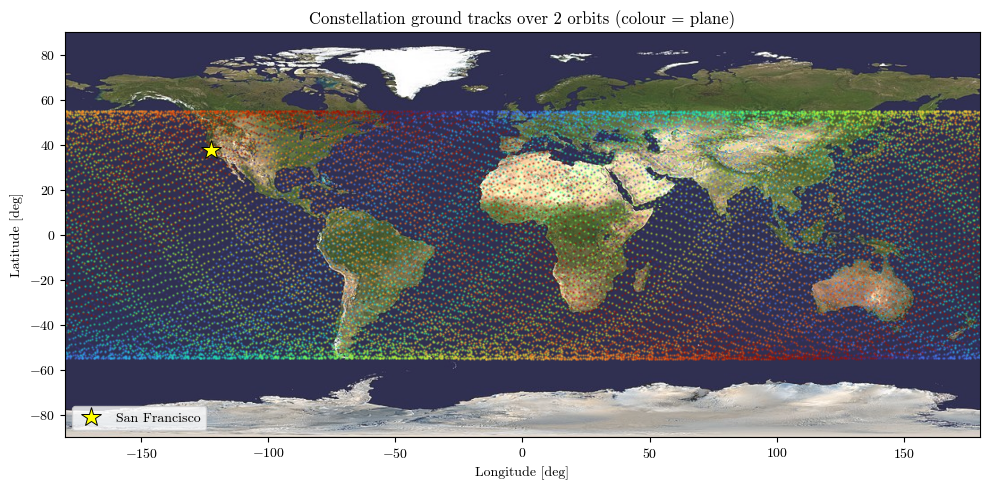

In [7]:
lla = np.array(
    [np.asarray(pnt.cart_to_lat_lon_alt(POS_ITRF[k], R_EARTH)) for k in range(N_SAT)]
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(
    EARTH_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.85
)
for k in range(N_SAT):
    lon = ((lla[k, :, 1] + 180.0) % 360.0) - 180.0
    ax.scatter(
        lon, lla[k, :, 0], s=0.6, color=plane_hex[k // SATS_PER_PLANE], alpha=0.4
    )
ax.plot(
    -122.42, 37.77, "*", ms=15, color="yellow", mec="k", mew=0.7, label="San Francisco"
)
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.set_title("Constellation ground tracks over 2 orbits (colour = plane)")
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## 6. Coverage and PDOP

With line-of-sight unit vectors $\hat{\mathbf u}_i$ (local East-North-Up) to the visible satellites,
the geometry matrix stacks rows $[\hat u_E,\hat u_N,\hat u_U,1]$ and

$$Q=(H^{\top}H)^{-1},\qquad \text{PDOP}=\sqrt{Q_{11}+Q_{22}+Q_{33}}.$$

We map the **median PDOP** over the two-orbit window on a $4^\circ$ grid. A $55^\circ$-inclination LEO
fleet serves a broad **mid-latitude band** well (San Francisco included) and thins out toward the
poles &mdash; the characteristic footprint of an inclined Walker constellation.


In [8]:
MASK_DEG = 5.0
MASK = np.deg2rad(MASK_DEG)
SF = (37.7749, -122.4194)  # San Francisco (lat N, lon E)


def pdop_stack(u_enu, visible):
    H = np.concatenate([u_enu, np.ones(u_enu.shape[:-1] + (1,))], axis=-1)
    Hw = H * visible[..., None]
    M = np.einsum("...sa,...sb->...ab", Hw, H)
    bad = visible.sum(axis=-1) < 4
    M[bad] = np.eye(4)
    Minv = np.linalg.inv(M)
    pdop = np.sqrt(
        np.clip(Minv[..., 0, 0] + Minv[..., 1, 1] + Minv[..., 2, 2], 0.0, None)
    )
    pdop[bad] = np.nan
    return pdop


LAT_G = np.arange(-82.0, 82.1, 4.0)
LON_G = np.arange(-180.0, 180.0, 4.0)
sub = slice(0, N_T, 2)  # subsample time to keep the map fast
PF = POS_ITRF[:, sub, :]
med_pdop = np.full((len(LAT_G), len(LON_G)), np.nan)
mean_vis = np.zeros_like(med_pdop)

for i, la in enumerate(np.deg2rad(LAT_G)):
    lo = np.deg2rad(LON_G)
    E = np.stack([-np.sin(lo), np.cos(lo), np.zeros_like(lo)], -1)
    Nn = np.stack(
        [
            -np.sin(la) * np.cos(lo),
            -np.sin(la) * np.sin(lo),
            np.full_like(lo, np.cos(la)),
        ],
        -1,
    )
    Up = np.stack(
        [
            np.cos(la) * np.cos(lo),
            np.cos(la) * np.sin(lo),
            np.full_like(lo, np.sin(la)),
        ],
        -1,
    )
    ru = R_EARTH * Up
    los = PF[None, :, :, :] - ru[:, None, None, :]
    e = np.einsum("lc,lstc->lst", E, los)
    n = np.einsum("lc,lstc->lst", Nn, los)
    u = np.einsum("lc,lstc->lst", Up, los)
    rng = np.sqrt(e**2 + n**2 + u**2)
    vis = np.arcsin(np.clip(u / rng, -1, 1)) >= MASK
    u_enu = np.moveaxis(np.stack([e / rng, n / rng, u / rng], -1), 1, 2)
    pdop = pdop_stack(u_enu, np.moveaxis(vis, 1, 2))
    covered = ~np.all(np.isnan(pdop), axis=1)  # cells that ever see >= 4 sats
    med_pdop[i, covered] = np.nanmedian(
        pdop[covered], axis=1
    )  # leave uncovered cells NaN
    mean_vis[i] = vis.sum(1).mean(1)

band = np.abs(LAT_G) <= 60
print(
    f"Median PDOP over the |lat|<=60 deg service band : {np.nanmedian(med_pdop[band]):.2f}"
)
print(f"Mean satellites in view (that band)             : {mean_vis[band].mean():.2f}")

Median PDOP over the |lat|<=60 deg service band : 6.65
Mean satellites in view (that band)             : 3.50


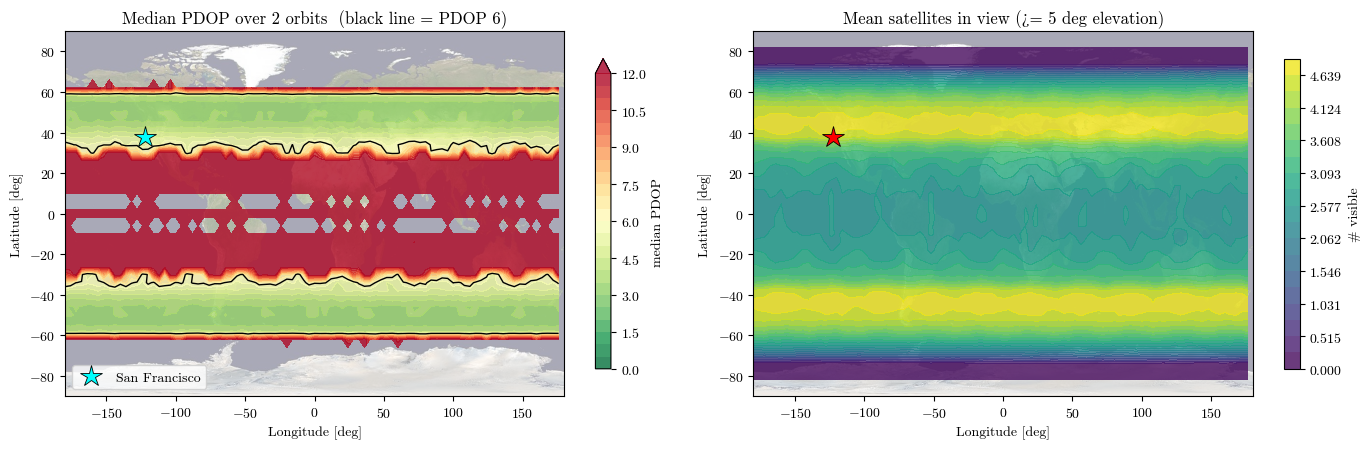

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

ax = axes[0]
ax.imshow(
    EARTH_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.35
)
cf = ax.contourf(
    LON_G,
    LAT_G,
    np.clip(med_pdop, 0, 12),
    levels=np.linspace(0, 12, 25),
    cmap="RdYlGn_r",
    alpha=0.8,
    extend="max",
)
ax.contour(
    LON_G, LAT_G, np.clip(med_pdop, 0, 12), levels=[6], colors="k", linewidths=1.0
)
ax.plot(SF[1], SF[0], "*", ms=16, color="cyan", mec="k", mew=0.6, label="San Francisco")
ax.set_title("Median PDOP over 2 orbits  (black line = PDOP 6)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
ax.legend(loc="lower left")
plt.colorbar(cf, ax=ax, label="median PDOP", shrink=0.85)

ax = axes[1]
ax.imshow(
    EARTH_MAP, extent=[-180, 180, -90, 90], aspect="auto", origin="upper", alpha=0.35
)
cf2 = ax.contourf(
    LON_G,
    LAT_G,
    mean_vis,
    levels=np.linspace(0, mean_vis.max(), 20),
    cmap="viridis",
    alpha=0.8,
)
ax.plot(SF[1], SF[0], "*", ms=16, color="red", mec="k", mew=0.6)
ax.set_title("Mean satellites in view (>= 5 deg elevation)")
ax.set_xlabel("Longitude [deg]")
ax.set_ylabel("Latitude [deg]")
plt.colorbar(cf2, ax=ax, label="# visible", shrink=0.85)

plt.tight_layout()
plt.show()

## 7. User positioning in San Francisco

Finally, the user experience. At **San Francisco** ($37.77^\circ$N, $122.42^\circ$W) we form a
pseudorange to every visible satellite,

$$\rho_i = \lVert \mathbf r_i - \mathbf r_u\rVert + c\,\delta t + \varepsilon_i,\qquad
\varepsilon_i\sim\mathcal N(0,\sigma^2),$$

with a receiver clock bias $c\,\delta t$ and $\sigma=1$&nbsp;m ranging noise, and solve for position and
clock by iterated least squares whenever four or more satellites are in view. (LEO satellites sit close
overhead, so we seed the solver at a coarse surface point beneath the visible set rather than at Earth's
centre.)


In [10]:
def enu_basis(lat, lon):
    cl, sl, co, so = np.cos(lat), np.sin(lat), np.cos(lon), np.sin(lon)
    return np.array([[-so, co, 0.0], [-sl * co, -sl * so, cl], [cl * co, cl * so, sl]])


lat_u, lon_u = np.deg2rad(SF[0]), np.deg2rad(SF[1])
r_user = R_EARTH * np.array(
    [np.cos(lat_u) * np.cos(lon_u), np.cos(lat_u) * np.sin(lon_u), np.sin(lat_u)]
)
Renu = enu_basis(lat_u, lon_u)

los = POS_ITRF - r_user[None, None, :]
enu = np.einsum("ij,ktj->kti", Renu, los)
rng_u = np.linalg.norm(enu, axis=-1)
elev_u = np.arcsin(np.clip(enu[..., 2] / rng_u, -1, 1))
az_u = np.arctan2(enu[..., 0], enu[..., 1])
vis_u = elev_u >= MASK

SIGMA = 1.0
rng_gen = np.random.default_rng(0)
err3d, err_h, err_v, epochs_fix, pdop_fix, nvis_fix = [], [], [], [], [], []
n_visible = vis_u.sum(0)

for tt in range(N_T):
    m = vis_u[:, tt]
    if m.sum() < 4:
        continue
    sats = POS_ITRF[m, tt, :]
    rho = (
        np.linalg.norm(sats - r_user, axis=1) + rng_gen.standard_normal(m.sum()) * SIGMA
    )
    x = np.concatenate([R_EARTH * (sats.mean(0) / np.linalg.norm(sats.mean(0))), [0.0]])
    converged = False
    for _ in range(20):
        d = x[:3] - sats
        r = np.linalg.norm(d, axis=1)
        H = np.concatenate([d / r[:, None], np.ones((m.sum(), 1))], axis=1)
        dx = np.linalg.lstsq(H, rho - (r + x[3]), rcond=None)[0]
        x += dx
        if np.linalg.norm(dx[:3]) < 1e-3:
            converged = True
            break
    if not converged or abs(np.linalg.norm(x[:3]) - R_EARTH) > 5e5:
        continue  # drop degenerate / divergent geometries
    derr = Renu @ (x[:3] - r_user)
    err3d.append(np.linalg.norm(derr))
    err_h.append(np.hypot(derr[0], derr[1]))
    err_v.append(abs(derr[2]))
    epochs_fix.append((TS[tt] - EPOCH) / 60.0)
    Q = np.linalg.inv(H.T @ H)
    pdop_fix.append(np.sqrt(Q[0, 0] + Q[1, 1] + Q[2, 2]))
    nvis_fix.append(int(m.sum()))

err3d = np.array(err3d)
err_h = np.array(err_h)
err_v = np.array(err_v)
pdop_fix = np.array(pdop_fix)
epochs_fix = np.array(epochs_fix)

print(
    f"Satellites in view at SF : min {n_visible.min()}, mean {n_visible.mean():.1f}, "
    f"max {n_visible.max()}"
)
print(f"Epochs with a fix        : {len(err3d)} / {N_T} ({100*len(err3d)/N_T:.0f}%)")
print(
    f"3-D position error   median {np.median(err3d):6.1f} m   95% {np.percentile(err3d,95):6.1f} m"
)
print(f"  horizontal         median {np.median(err_h):6.1f} m")
print(f"  vertical           median {np.median(err_v):6.1f} m")
print(f"PDOP at fix epochs    median {np.median(pdop_fix):.2f}")

Satellites in view at SF : min 2, mean 4.5, max 6
Epochs with a fix        : 166 / 194 (86%)
3-D position error   median    3.3 m   95%   15.6 m
  horizontal         median    1.3 m
  vertical           median    2.9 m
PDOP at fix epochs    median 4.94


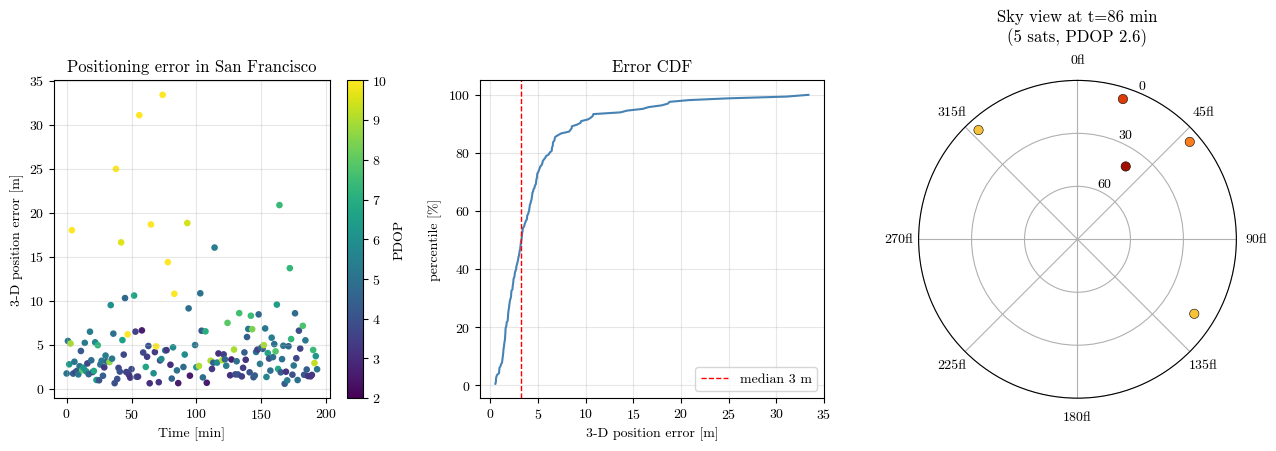

In [11]:
fig = plt.figure(figsize=(13, 4.4))

ax = fig.add_subplot(1, 3, 1)
sc = ax.scatter(epochs_fix, err3d, c=pdop_fix, cmap="viridis", s=14, vmin=2, vmax=10)
ax.set_xlabel("Time [min]")
ax.set_ylabel("3-D position error [m]")
ax.set_title("Positioning error in San Francisco")
ax.grid(alpha=0.3)
plt.colorbar(sc, ax=ax, label="PDOP")

ax = fig.add_subplot(1, 3, 2)
xs = np.sort(err3d)
ys = np.arange(1, len(xs) + 1) / len(xs)
ax.plot(xs, ys * 100, color="steelblue")
ax.axvline(
    np.median(err3d),
    color="red",
    ls="--",
    lw=1,
    label=f"median {np.median(err3d):.0f} m",
)
ax.set_xlabel("3-D position error [m]")
ax.set_ylabel("percentile [%]")
ax.set_title("Error CDF")
ax.grid(alpha=0.3)
ax.legend()

ax = fig.add_subplot(1, 3, 3, projection="polar")
best = np.argmin(pdop_fix)
tt = int(round(epochs_fix[best] * 60.0 / DT))
m = vis_u[:, tt]
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.scatter(
    az_u[m, tt],
    90 - np.rad2deg(elev_u[m, tt]),
    c=[plane_hex[k // SATS_PER_PLANE] for k in np.where(m)[0]],
    s=45,
    edgecolors="k",
    lw=0.4,
)
ax.set_rmax(90)
ax.set_rticks([30, 60, 90])
ax.set_yticklabels(["60", "30", "0"])
ax.set_title(
    f"Sky view at t={epochs_fix[best]:.0f} min\n({m.sum()} sats, PDOP {pdop_fix[best]:.1f})",
    va="bottom",
)

plt.tight_layout()
plt.show()

## 8. On-board orbit determination (ODTS) with GPS

There is a flip side to the service above: before a LEO PNT satellite can *broadcast* its position, it
has to **know** it. Each satellite carries its own GPS receiver and runs an **on-board orbit- and
time-determination (ODTS) filter** &mdash; from ~600&nbsp;km it looks *up* at the GPS constellation
(~20,200&nbsp;km) and sees most of it at once. This is also where drag comes back: the on-board filter
uses a cheap gravity-only dynamics model and lets the GPS measurements plus **process noise** soak up
the unmodeled drag.

We estimate the state $\mathbf x = [\mathbf r,\ \mathbf v,\ b,\ d]$ &mdash; position, velocity, receiver
clock bias $b$ and drift $d$ &mdash; with an **Extended Kalman Filter**:

* **predict** &mdash; the orbit is propagated with `NBodyDynamics`, whose `propagate_stm_with_info`
  returns both the state and the $6\times6$ state-transition matrix for the covariance; the clock uses
  $b\leftarrow b + d\,\Delta t$;
* **update** &mdash; each visible GPS satellite gives an iono-free pseudorange
  $\rho = \lVert\mathbf r_\text{GPS}-\mathbf r\rVert + b + \varepsilon$ ($\sigma=1$&nbsp;m), with
  measurement row $[-\hat{\mathbf e}^{\top},\,\mathbf 0^{\top},\,1,\,0]$.

We first build a nominal GPS constellation to range against.


In [12]:
# nominal GPS: Walker 24/6/2, ~20,200 km, 55 deg -- stable MEO, propagated two-body (truth)
GPS_COES = walker_elements(24, 6, 2, R_EARTH + 20200e3, 0.0, 55.0 * RAD)
gps_dyn = pnt.CartesianTwoBodyDynamics(GM_EARTH)

DT_ODTS = 30.0  # measurement cadence [s]
TS_ODTS = EPOCH + np.arange(0.0, 2 * PERIOD, DT_ODTS)
N_ODTS = len(TS_ODTS)

# Truth: LEO nav-satellite 0 propagated WITH drag, and the GPS satellites.
leo_truth = np.asarray(dyn.propagate(RV0[0], TS_ODTS))  # (N,6): [r, v] in GCRF
gps_truth = np.array(
    [
        np.asarray(gps_dyn.propagate(pnt.classical_to_cart(c, GM_EARTH), TS_ODTS))[
            :, :3
        ]
        for c in GPS_COES
    ]
)  # (24,N,3)


def gps_visible(r_leo, r_gps, r_occ):
    """True if the LEO->GPS line of sight clears the Earth (occulting radius r_occ)."""
    d = r_gps - r_leo
    L = np.linalg.norm(d)
    u = d / L
    s = -np.dot(r_leo, u)  # foot of perpendicular from Earth centre
    if s < 0 or s > L:
        return True
    return np.linalg.norm(r_leo + s * u) > r_occ


R_OCC = R_EARTH + 50e3
n_gps_view = np.array(
    [
        sum(gps_visible(leo_truth[k, :3], gps_truth[j, k], R_OCC) for j in range(24))
        for k in range(N_ODTS)
    ]
)
print(
    f"GPS satellites in view from the LEO receiver: "
    f"min {n_gps_view.min()}, mean {n_gps_view.mean():.1f}, max {n_gps_view.max()}"
)

GPS satellites in view from the LEO receiver: min 12, mean 14.0, max 16


### Run the Extended Kalman Filter

The truth orbit includes drag; the filter's dynamics model does **not** &mdash; that mismatch is what the
process noise `Q_ACC` represents. We start the filter 2&nbsp;km and 2&nbsp;m/s off with a wrong clock,
and let GPS pull it in.


In [13]:
dyn_filter = make_dynamics(drag=False)  # on-board model: gravity only (drag unmodeled)

SIGMA_RHO = 1.0  # iono-free pseudorange noise [m]
Q_ACC = 1e-5  # dynamics process noise (accel) [m/s^2]
Q_CLK = 5e-4  # clock-drift random walk [m/s/sqrt(s)]

# Truth receiver clock: bias b [m] and drift d [m/s] (slowly wandering).
rng = np.random.default_rng(1)
b_true = np.zeros(N_ODTS)
d_true = np.zeros(N_ODTS)
b_true[0], d_true[0] = 30.0, 0.20
for k in range(1, N_ODTS):
    d_true[k] = d_true[k - 1] + rng.standard_normal() * 1e-4 * np.sqrt(DT_ODTS)
    b_true[k] = b_true[k - 1] + d_true[k - 1] * DT_ODTS

# Initial estimate: truth + gross errors.
x = np.concatenate([RV0[0].astype(float), [b_true[0] + 80.0, d_true[0] + 0.4]])
x[:3] += rng.standard_normal(3) * 2000.0  # 2 km position error
x[3:6] += rng.standard_normal(3) * 2.0  # 2 m/s velocity error
P = np.diag([3e3**2] * 3 + [3.0] * 3 + [300.0**2, 1.0**2])

pos_err, pos_3sig, clk_err, clk_3sig = [], [], [], []
for k in range(N_ODTS):
    if k > 0:
        # --- predict: native STM for the orbit, analytic model for the clock ---
        xf, stm, _ = dyn_filter.propagate_stm_with_info(
            x[:6], TS_ODTS[k - 1], TS_ODTS[k]
        )
        x[:6] = np.asarray(xf)
        x[6] += x[7] * DT_ODTS
        Phi = np.eye(8)
        Phi[:6, :6] = np.asarray(stm)
        Phi[6, 7] = DT_ODTS
        Q = np.zeros((8, 8))
        Q[0:3, 0:3] = np.eye(3) * Q_ACC**2 * DT_ODTS**3 / 3
        Q[0:3, 3:6] = np.eye(3) * Q_ACC**2 * DT_ODTS**2 / 2
        Q[3:6, 0:3] = Q[0:3, 3:6].T
        Q[3:6, 3:6] = np.eye(3) * Q_ACC**2 * DT_ODTS
        Q[6, 6] = Q_CLK**2 * DT_ODTS**3 / 3
        Q[7, 7] = Q_CLK**2 * DT_ODTS
        P = Phi @ P @ Phi.T + Q

    # a-priori errors (current estimate before this epoch's measurements)
    pos_err.append(np.linalg.norm(x[:3] - leo_truth[k, :3]))
    pos_3sig.append(3 * np.sqrt(P[0, 0] + P[1, 1] + P[2, 2]))
    clk_err.append(x[6] - b_true[k])
    clk_3sig.append(3 * np.sqrt(P[6, 6]))

    # --- update: one pseudorange per visible GPS satellite ---
    r_leo = leo_truth[k, :3]
    vis = [j for j in range(24) if gps_visible(r_leo, gps_truth[j, k], R_OCC)]
    H = np.zeros((len(vis), 8))
    y = np.zeros(len(vis))
    for i, j in enumerate(vis):
        r_gps = gps_truth[j, k]
        rho = (
            np.linalg.norm(r_gps - r_leo)
            + b_true[k]
            + rng.standard_normal() * SIGMA_RHO
        )
        rho_pred = np.linalg.norm(r_gps - x[:3])
        H[i, :3] = -(r_gps - x[:3]) / rho_pred  # d(range)/d(r)
        H[i, 6] = 1.0  # d(range)/d(clock bias)
        y[i] = rho - (rho_pred + x[6])
    K = P @ H.T @ np.linalg.inv(H @ P @ H.T + np.eye(len(vis)) * SIGMA_RHO**2)
    x = x + K @ y
    P = (np.eye(8) - K @ H) @ P

pos_err = np.array(pos_err)
pos_3sig = np.array(pos_3sig)
clk_err = np.array(clk_err)
clk_3sig = np.array(clk_3sig)
t_min = (TS_ODTS - EPOCH) / 60.0
half = N_ODTS // 2
print(
    f"Position: initial error {pos_err[0]/1e3:.2f} km  ->  steady-state RMS "
    f"{np.sqrt(np.mean(pos_err[half:] ** 2)):.2f} m"
)
print(
    f"Clock bias: steady-state estimation error RMS {np.sqrt(np.mean(clk_err[half:] ** 2)):.2f} m "
    f"({np.sqrt(np.mean(clk_err[half:] ** 2))/299792458.0*1e9:.2f} ns)"
)
print(
    f"Filter consistency: {100*np.mean(pos_err[half:] < pos_3sig[half:]):.0f}% of steady-state "
    f"epochs have |error| < 3-sigma"
)

Position: initial error 2.56 km  ->  steady-state RMS 0.32 m


Clock bias: steady-state estimation error RMS 0.24 m (0.79 ns)
Filter consistency: 100% of steady-state epochs have |error| < 3-sigma


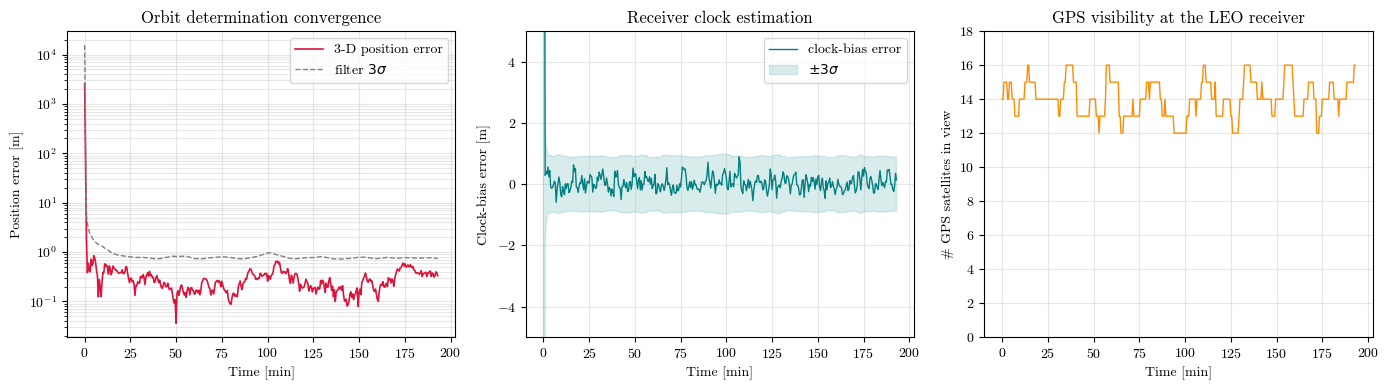

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.0))

ax = axes[0]
ax.semilogy(t_min, pos_err, color="crimson", lw=1.2, label="3-D position error")
ax.semilogy(t_min, pos_3sig, color="gray", lw=1.0, ls="--", label=r"filter $3\sigma$")
ax.set_xlabel("Time [min]")
ax.set_ylabel("Position error [m]")
ax.set_title("Orbit determination convergence")
ax.grid(alpha=0.3, which="both")
ax.legend()

ax = axes[1]
ax.plot(t_min, clk_err, color="teal", lw=1.0, label="clock-bias error")
ax.fill_between(
    t_min, -clk_3sig, clk_3sig, color="teal", alpha=0.15, label=r"$\pm3\sigma$"
)
ax.set_xlabel("Time [min]")
ax.set_ylabel("Clock-bias error [m]")
ax.set_ylim(-5, 5)
ax.set_title("Receiver clock estimation")
ax.grid(alpha=0.3)
ax.legend()

ax = axes[2]
ax.plot(t_min, n_gps_view, color="darkorange", lw=1.0)
ax.set_xlabel("Time [min]")
ax.set_ylabel("# GPS satellites in view")
ax.set_ylim(0, n_gps_view.max() + 2)
ax.set_title("GPS visibility at the LEO receiver")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Using LuPNT's native Earth model end to end, we built a simple LEO PNT study:

* an Earth force model with **$J_2$ (EGM96) plus Harris-Priester atmospheric drag** via `Body.Earth`
  and `NBodyDynamics.set_drag_coeff`, with the drag term shown directly by `compute_accelerations`;
* a demonstration that **ignoring drag** mispredicts a 600&nbsp;km satellite by kilometres within days
  &mdash; the reason a LEO PNT operator must model it;
* a **110/10/1 Walker constellation** at 600&nbsp;km, propagated with `NBodyDynamics` and expressed in
  `GCRF` / `ITRF` via `convert_frame`;
* **coverage and PDOP maps** showing a strong mid-latitude service band;
* a **pseudorange least-squares positioning** simulation in San Francisco, reaching few metres
  accuracy with continuous four-plus-satellite visibility; and
* an **on-board GPS orbit-determination EKF** for one satellite &mdash; using LuPNT's native STM
  propagation and iono-free pseudoranges &mdash; that pulls a 2&nbsp;km initial error down to
  sub-metre and estimates the receiver clock to the nanosecond, with process noise absorbing the
  drag the on-board model omits.

Together with the lunar tutorials and the Mars example (Example&nbsp;15), this shows LuPNT's PNT
machinery spanning from **LEO to the Moon to Mars** &mdash; the same propagator, frames, and geometry
tools, with only the central body and its forces (here, atmospheric drag) changing.
